Mount Drive

In [6]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


Clone Repo

In [4]:
import os

repo_url = "https://YOUR_TOKEN@github.com/augusthao6/stock-predictions.git"
gdrive_repo_path = "/content/gdrive/MyDrive/stock-predictions"

%cd /content/gdrive/MyDrive/

if not os.path.exists(gdrive_repo_path + "/.git"):
    # Either doesn't exist or exists but isn't a git repo — clone fresh
    !rm -rf {gdrive_repo_path}
    !git clone {repo_url} stock-predictions
else:
    print("Repo already exists, pulling latest changes...")
    %cd {gdrive_repo_path}
    !git pull

/content/gdrive/MyDrive
Cloning into 'stock-predictions'...
remote: Enumerating objects: 68, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (63/63), done.
remote: Total 68 (delta 1), reused 68 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (68/68), 111.99 KiB | 2.15 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [7]:
%cd /content/gdrive/MyDrive/stock-predictions

/content/gdrive/MyDrive/stock-predictions


# Data collection and preprocessing

In [8]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data.collector import StockDataCollector
from src.data.preprocessor import DataPreprocessor
from src.features.technical import TechnicalIndicators

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA']
print('Setup complete')

Setup complete


Collect data through yfinance API

In [9]:
collector = StockDataCollector(tickers=TICKERS)
prices = collector.download_prices(start='2017-04-26', end='2026-04-26')

summary = collector.get_collection_summary(prices)
print('Collection Summary:')
for k, v in summary.items():
    print(f'  {k}: {v}')

print(f'\nDataFrame shape: {prices.shape}')
print(f'Date range: {prices.index.min().date()} to {prices.index.max().date()}')
print(f'Trading days: {len(prices)}')

Collection Summary:
  tickers: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA']
  n_tickers: 5
  date_range: 2017-04-26 to 2026-04-24
  n_trading_days: 2262
  total_observations: 11310
  fields: ['Open', 'High', 'Low', 'Close', 'Volume']
  source: Yahoo Finance API via yfinance
  collection_method: Programmatic API integration with retry logic and caching

DataFrame shape: (2262, 25)
Date range: 2017-04-26 to 2026-04-24
Trading days: 2262


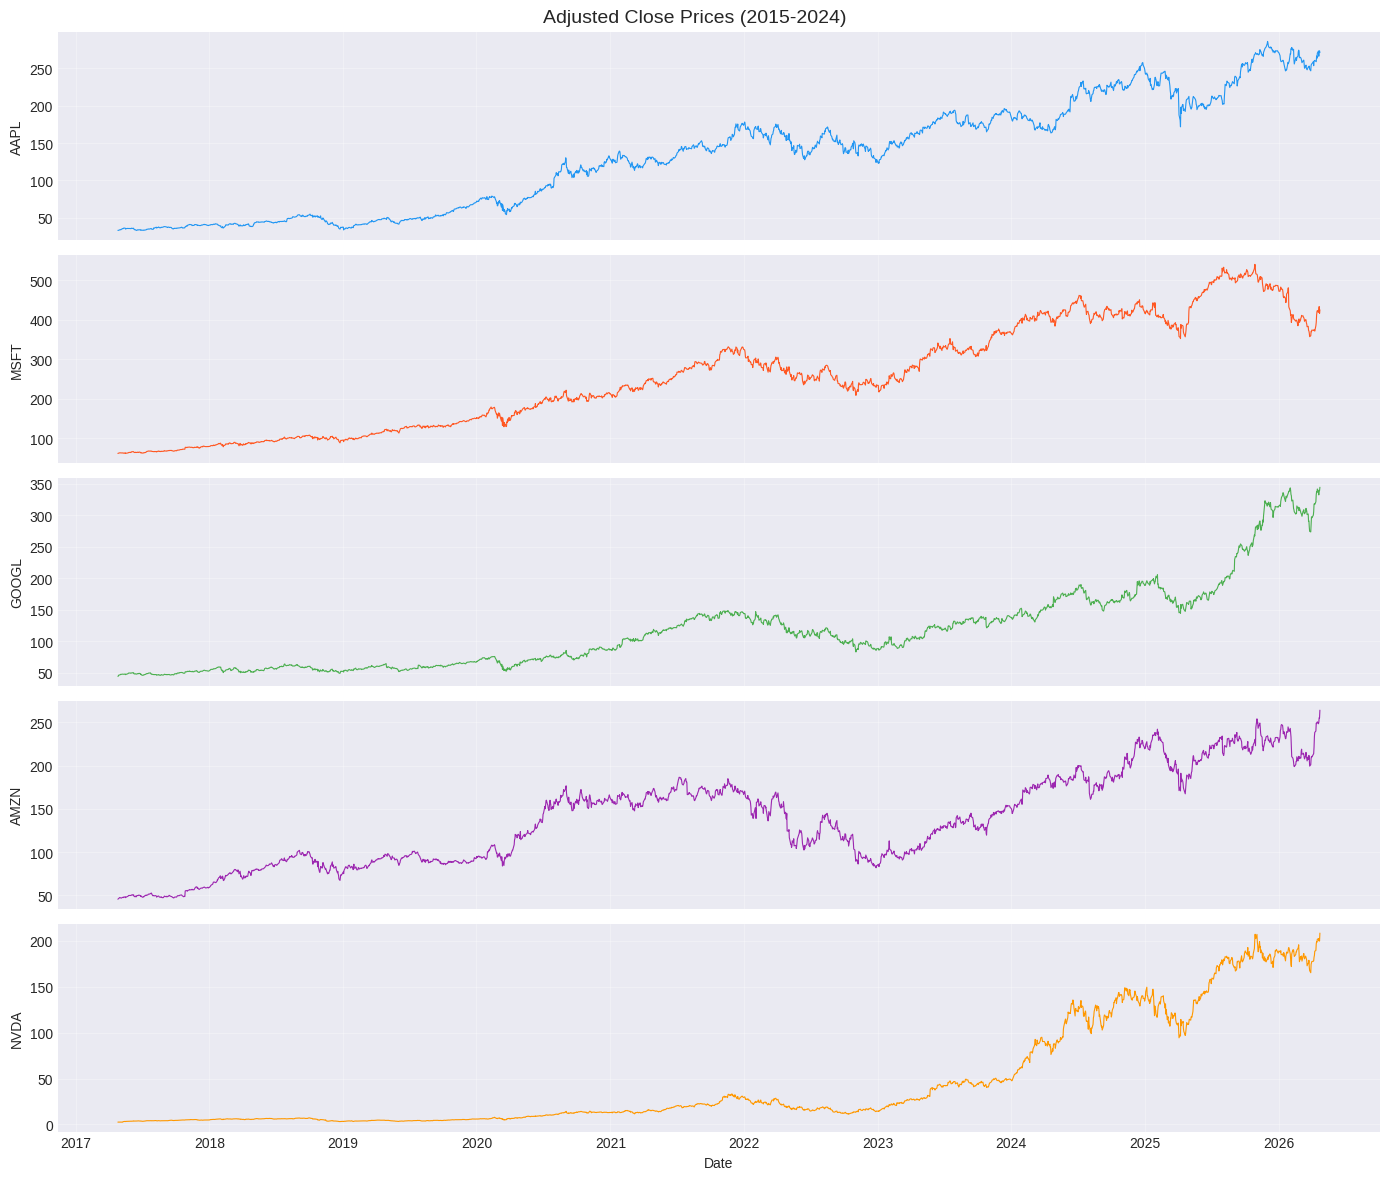

In [11]:
import os

# Plot adjusted close prices for all tickers
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(14, 12), sharex=True)
colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']

for i, (ticker, color) in enumerate(zip(TICKERS, colors)):
    close = prices[ticker]['Close']
    axes[i].plot(close.index, close.values, color=color, linewidth=0.8)
    axes[i].set_ylabel(ticker)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
fig.suptitle('Adjusted Close Prices (2015-2024)', fontsize=14)
plt.tight_layout()

# Ensure the directory exists before saving
os.makedirs('../docs', exist_ok=True)
plt.savefig('../docs/price_history.png', dpi=150, bbox_inches='tight')
plt.show()

Missing Value Analysis

In [12]:
preprocessor = DataPreprocessor()

# Check missing values per ticker/field
missing_stats = []
for ticker in TICKERS:
    ohlcv = prices[ticker]
    n_missing = ohlcv.isnull().sum().sum()
    n_total = ohlcv.size
    missing_stats.append({'Ticker': ticker, 'Missing': n_missing, 'Total': n_total,
                          'Missing %': f'{100*n_missing/n_total:.3f}%'})

missing_df = pd.DataFrame(missing_stats)
print('Missing Value Analysis (before imputation):')
print(missing_df.to_string(index=False))

# After imputation
aapl_clean, mv_stats = preprocessor.handle_missing_values(prices['AAPL'].copy())
print(f'\nImputation stats for AAPL: {mv_stats}')

Missing Value Analysis (before imputation):
Ticker  Missing  Total Missing %
  AAPL        0  11310    0.000%
  MSFT        0  11310    0.000%
 GOOGL        0  11310    0.000%
  AMZN        0  11310    0.000%
  NVDA        0  11310    0.000%

Imputation stats for AAPL: {'missing_before': 0, 'missing_after': 0, 'imputed': 0, 'imputation_rate': 0.0}


Outlier Analysis

Outlier stats: {'outliers_clipped': 24, 'iqr_multiplier': 3.0, 'clip_bounds_sample': {'Return': {'lower': -0.06130217354600642, 'upper': 0.06404712733885876}}}


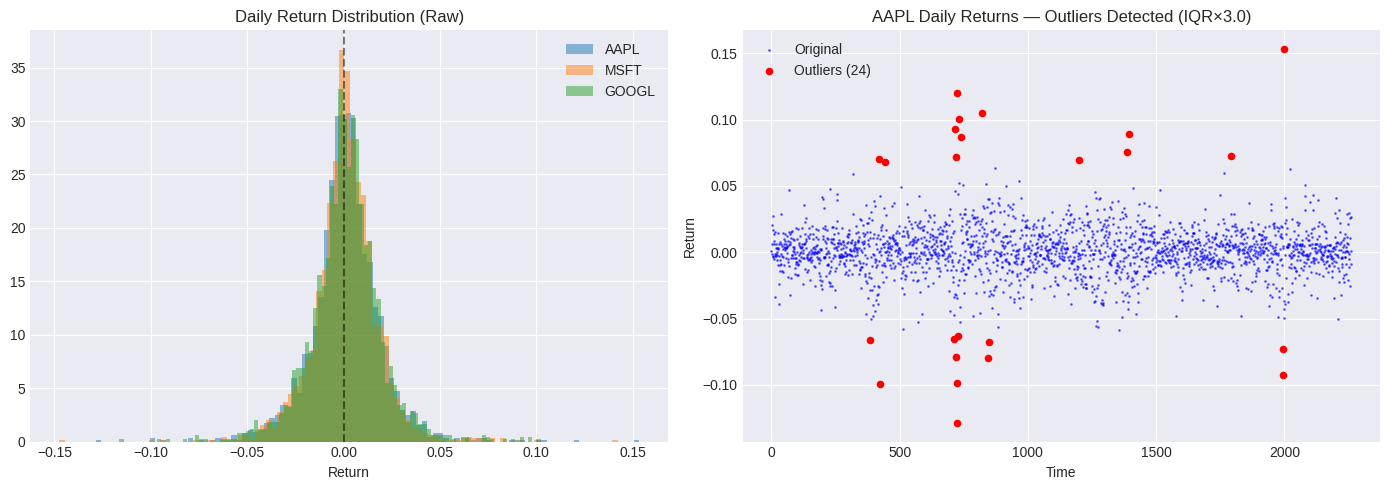

In [13]:
# Compute returns and identify outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ticker in TICKERS[:3]:
    close = prices[ticker]['Close'].dropna()
    returns = close.pct_change().dropna()
    axes[0].hist(returns, bins=100, alpha=0.5, label=ticker, density=True)

axes[0].set_title('Daily Return Distribution (Raw)')
axes[0].set_xlabel('Return')
axes[0].legend()
axes[0].axvline(x=0, color='black', linestyle='--', alpha=0.5)

# Identify outliers using IQR
aapl_returns = prices['AAPL']['Close'].pct_change().dropna().to_frame(name='Return')
clipped, out_stats = preprocessor.clip_return_outliers(aapl_returns.copy())

axes[1].scatter(range(len(aapl_returns)), aapl_returns['Return'],
                s=1, alpha=0.5, color='blue', label='Original')
outlier_mask = aapl_returns['Return'] != clipped['Return']
axes[1].scatter(np.where(outlier_mask)[0], aapl_returns.loc[outlier_mask, 'Return'],
                s=20, color='red', label=f'Outliers ({outlier_mask.sum()})', zorder=5)
axes[1].set_title(f'AAPL Daily Returns — Outliers Detected (IQR×{preprocessor.iqr_multiplier})')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Return')
axes[1].legend()

print(f'Outlier stats: {out_stats}')
plt.tight_layout()
plt.savefig('../docs/outlier_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Class Imbalance

AAPL: up=53.5%, class_weights={0: np.float64(1.075), 1: np.float64(0.935)}
MSFT: up=54.0%, class_weights={0: np.float64(1.087), 1: np.float64(0.926)}
GOOGL: up=53.8%, class_weights={0: np.float64(1.082), 1: np.float64(0.93)}
AMZN: up=53.2%, class_weights={0: np.float64(1.069), 1: np.float64(0.94)}
NVDA: up=54.3%, class_weights={0: np.float64(1.094), 1: np.float64(0.921)}


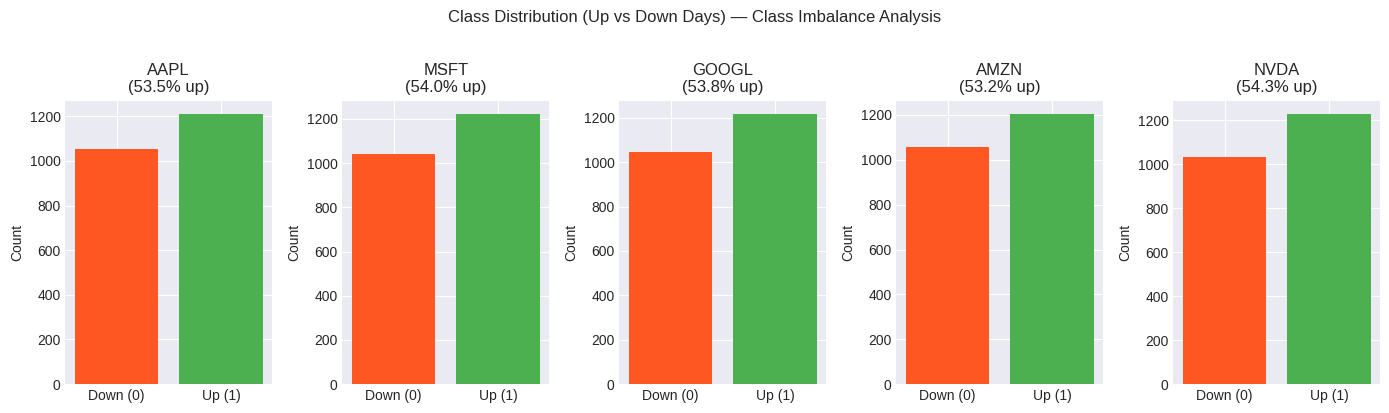

In [14]:
fig, axes = plt.subplots(1, len(TICKERS), figsize=(14, 4))

for i, ticker in enumerate(TICKERS):
    ohlcv, _ = preprocessor.preprocess_prices(prices, ticker)
    labels = (ohlcv['LogReturn'] > 0).astype(int).values
    counts = np.bincount(labels)
    pct_up = counts[1] / len(labels)

    axes[i].bar(['Down (0)', 'Up (1)'], counts, color=['#FF5722', '#4CAF50'])
    axes[i].set_title(f'{ticker}\n({pct_up:.1%} up)')
    axes[i].set_ylabel('Count')

    class_weights = preprocessor.compute_class_weights(labels)
    print(f'{ticker}: up={pct_up:.1%}, class_weights={dict(zip([0,1], class_weights.round(3)))}')

plt.suptitle('Class Distribution (Up vs Down Days) — Class Imbalance Analysis', y=1.02)
plt.tight_layout()
plt.savefig('../docs/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

Feature engineering - Technical Indicators

In [15]:
# Demonstrate technical indicator computation
aapl_ohlcv, _ = preprocessor.preprocess_prices(prices, 'AAPL')
features = TechnicalIndicators.compute_all(aapl_ohlcv)

print(f'Technical features computed: {features.shape[1]} features')
print(f'Feature names: {features.columns.tolist()}')
print(f'\nFirst few rows (after NaN period):')
print(features.dropna().head(3).to_string())

Technical features computed: 20 features
Feature names: ['LogReturn_1d', 'LogReturn_5d', 'LogReturn_20d', 'HighLow_Range', 'CloseOpen_Gap', 'RSI_14', 'RSI_7', 'MACD', 'MACD_Signal', 'MACD_Hist', 'ROC_10', 'ROC_5', 'BB_PctB', 'BB_Bandwidth', 'ATR_14', 'HV_20', 'SMA_Ratio_10_50', 'EMA_Ratio_12_26', 'OBV_Norm', 'Volume_Ratio']

First few rows (after NaN period):
            LogReturn_1d  LogReturn_5d  LogReturn_20d  HighLow_Range  CloseOpen_Gap     RSI_14      RSI_7      MACD  MACD_Signal  MACD_Hist    ROC_10     ROC_5   BB_PctB  BB_Bandwidth    ATR_14     HV_20  SMA_Ratio_10_50  EMA_Ratio_12_26  OBV_Norm  Volume_Ratio
Date                                                                                                                                                                                                                                                                 
2017-07-10      0.006085      0.007195      -0.026665       0.017786       0.006571  50.925933  61.841917 -0.34825

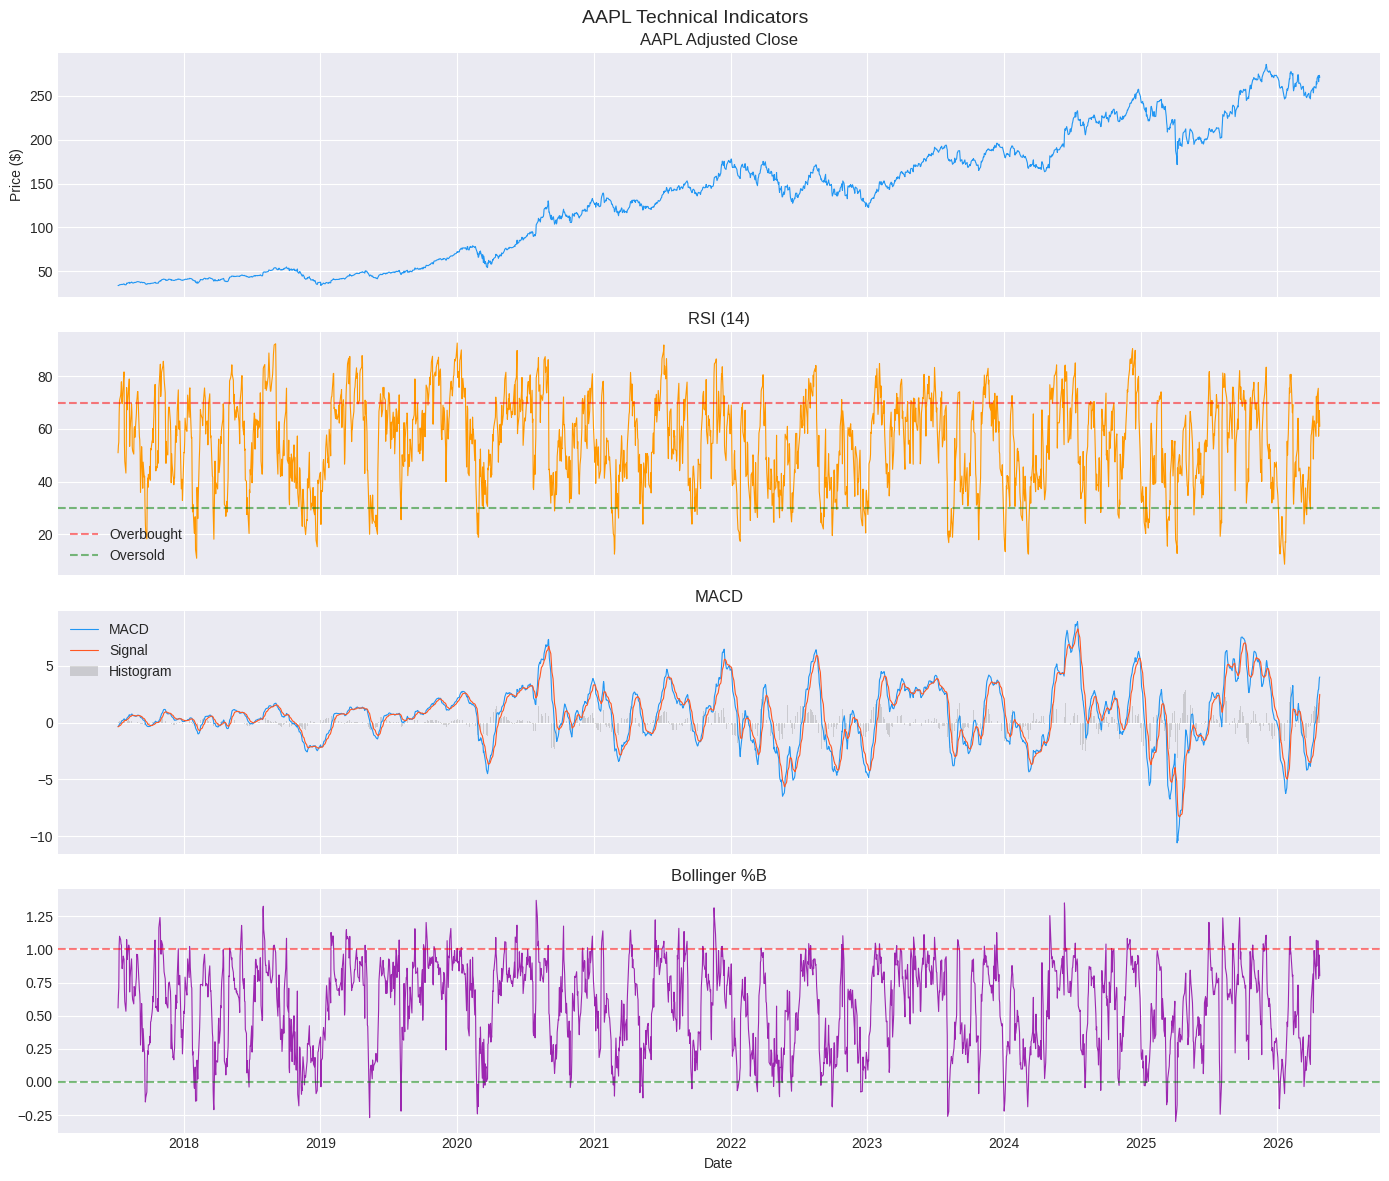

In [16]:
# Plot key technical indicators for AAPL
feat_clean = features.dropna()
close = aapl_ohlcv['Close'].loc[feat_clean.index]

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(close.index, close.values, color='#2196F3', linewidth=0.8)
axes[0].set_title('AAPL Adjusted Close')
axes[0].set_ylabel('Price ($)')

axes[1].plot(feat_clean.index, feat_clean['RSI_14'], color='#FF9800', linewidth=0.8)
axes[1].axhline(70, color='red', linestyle='--', alpha=0.5, label='Overbought')
axes[1].axhline(30, color='green', linestyle='--', alpha=0.5, label='Oversold')
axes[1].set_title('RSI (14)')
axes[1].legend()

axes[2].plot(feat_clean.index, feat_clean['MACD'], color='#2196F3', label='MACD', linewidth=0.8)
axes[2].plot(feat_clean.index, feat_clean['MACD_Signal'], color='#FF5722', label='Signal', linewidth=0.8)
axes[2].bar(feat_clean.index, feat_clean['MACD_Hist'], color='gray', alpha=0.3, label='Histogram')
axes[2].set_title('MACD')
axes[2].legend()

axes[3].plot(feat_clean.index, feat_clean['BB_PctB'], color='#9C27B0', linewidth=0.8)
axes[3].axhline(1.0, color='red', linestyle='--', alpha=0.5)
axes[3].axhline(0.0, color='green', linestyle='--', alpha=0.5)
axes[3].set_title('Bollinger %B')

axes[-1].set_xlabel('Date')
plt.suptitle('AAPL Technical Indicators', fontsize=14)
plt.tight_layout()
plt.savefig('../docs/technical_indicators.png', dpi=150, bbox_inches='tight')
plt.show()

Train/test/val split

Total samples: 2211
Train: 1547 samples (70.0%) | 2017-07-10 to 2023-08-30
Val:   332 samples (15.0%) | 2023-08-31 to 2024-12-24
Test:  332 samples (15.0%) | 2024-12-26 to 2026-04-24


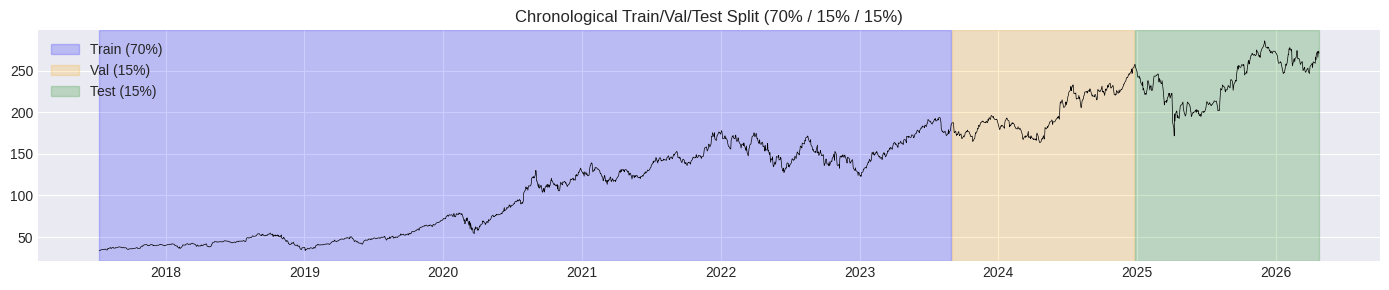

In [17]:
# Demonstrate the chronological split
full_df = feat_clean.join(aapl_ohlcv[['LogReturn']], how='inner').dropna()
train_df, val_df, test_df = preprocessor.train_val_test_split(full_df)

print(f'Total samples: {len(full_df)}')
print(f'Train: {len(train_df)} samples ({len(train_df)/len(full_df):.1%}) | {train_df.index[0].date()} to {train_df.index[-1].date()}')
print(f'Val:   {len(val_df)} samples ({len(val_df)/len(full_df):.1%}) | {val_df.index[0].date()} to {val_df.index[-1].date()}')
print(f'Test:  {len(test_df)} samples ({len(test_df)/len(full_df):.1%}) | {test_df.index[0].date()} to {test_df.index[-1].date()}')

# Visualize the split
fig, ax = plt.subplots(figsize=(14, 3))
ax.axvspan(train_df.index[0], train_df.index[-1], alpha=0.2, color='blue', label=f'Train (70%)')
ax.axvspan(val_df.index[0], val_df.index[-1], alpha=0.2, color='orange', label=f'Val (15%)')
ax.axvspan(test_df.index[0], test_df.index[-1], alpha=0.2, color='green', label=f'Test (15%)')
close_plot = aapl_ohlcv['Close'].loc[full_df.index]
ax.plot(close_plot.index, close_plot.values, color='black', linewidth=0.5)
ax.set_title('Chronological Train/Val/Test Split (70% / 15% / 15%)')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/data_split.png', dpi=150, bbox_inches='tight')
plt.show()

Feature correlation analysis

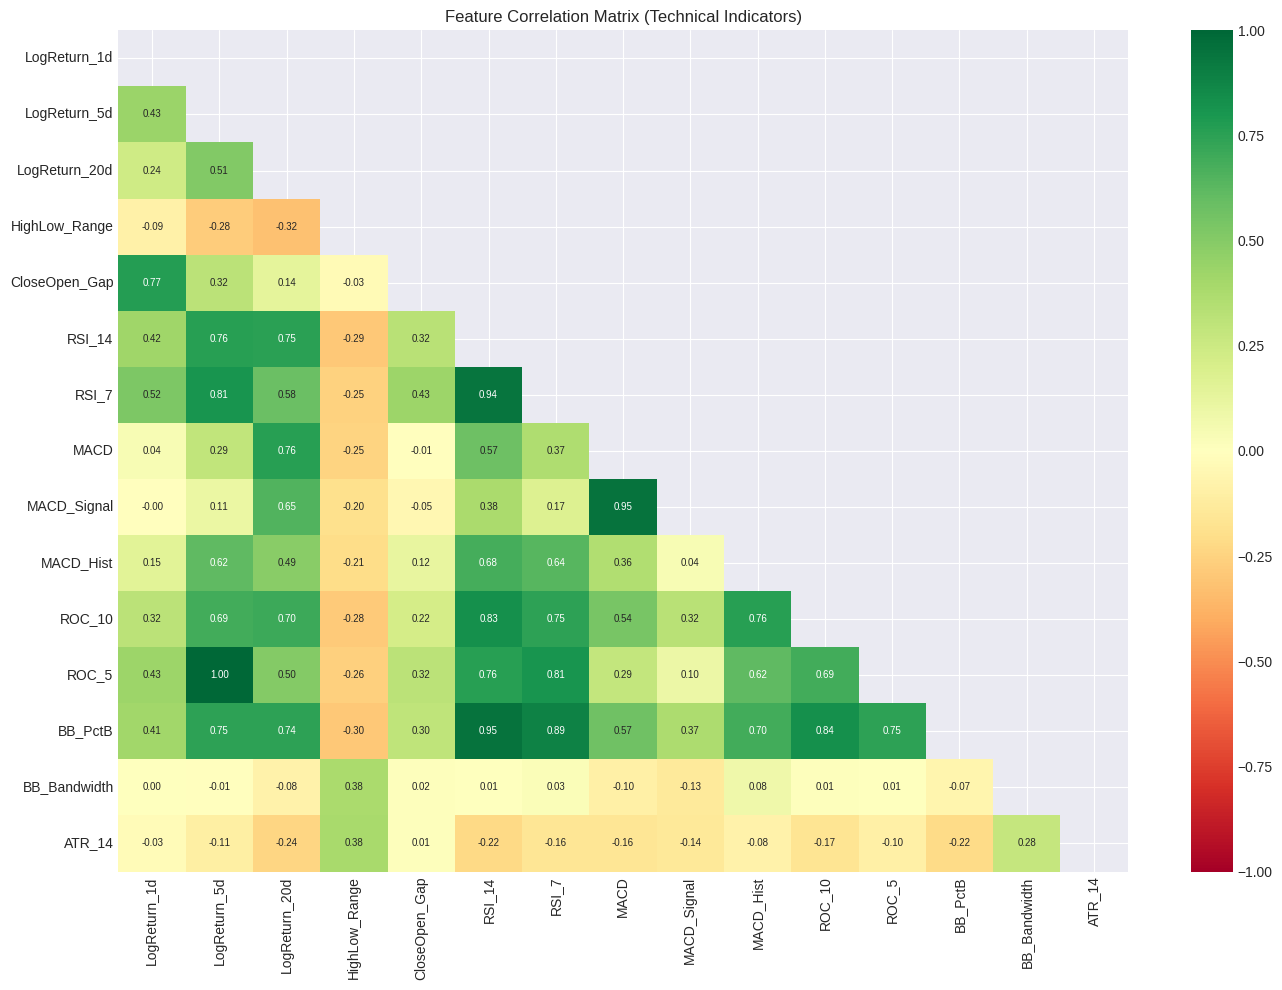


Data exploration complete. All visualizations saved to docs/


In [18]:
# Correlation heatmap of technical features
fig, ax = plt.subplots(figsize=(14, 10))
corr = feat_clean.iloc[:, :15].corr()  # first 15 features for readability
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix (Technical Indicators)')
plt.tight_layout()
plt.savefig('../docs/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nData exploration complete. All visualizations saved to docs/')